In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from _fractures import *

In [3]:
xmin,ymin,zmin,xmax,ymax,zmax,Nx,Ny,Nz,dx,dy,dz = get_grid_parameters()
dx

0.4

In [84]:
##IMPORT DATA AS A CSV FILE

data = pd.read_csv("energies_quantum_ricker_IC_1_6x6x6_-1to1_two_perp_xy_yz_0.0002_0.001")
#Define whether just classical values will be plotted
quantum = True

In [86]:
#View data
data

,total_quantum,total_classical,kinetic_quantum,kinetic_classical,potential_quantum,potential_classical,time,Layer #
0,58.386198,58.382475,18.914868,18.912791,39.471329,39.469684,0.0002,1
1,44.384016,44.383927,7.947897,7.948033,36.436116,36.435894,0.0002,2
2,2.087027,2.087097,0.892517,0.892541,1.194510,1.194556,0.0002,3
3,0.117375,0.117376,0.035640,0.035643,0.081732,0.081733,0.0002,4
4,0.003394,0.003394,0.000685,0.000686,0.002708,0.002708,0.0002,5
5,53.459791,53.446480,31.433395,31.432706,22.026398,22.013775,0.0004,1
6,44.230398,44.236128,28.721065,28.720211,15.509335,15.515917,0.0004,2
7,5.426362,5.428866,2.890720,2.891952,2.535643,2.536914,0.0004,3
8,1.265490,1.266365,0.548902,0.549402,0.716588,0.716963,0.0004,4
9,0.437347,0.437490,0.110603,0.110646,0.326748,0.326844,0.0004,5


In [88]:
def get_layer_dataframes(data):
    if (Nx<=6):
        data_layer_1 = data[data['Layer #']==1]
        data_layer_2 = data[data['Layer #']==2]
        data_layer_3 = data[data['Layer #']==3]
        data_layer_4 = data[data['Layer #']==4] 
        data_layer_5 = data[data['Layer #']==5]
        layer_names = [data_layer_1,data_layer_2,data_layer_3,data_layer_4,data_layer_5]
    else:
        data_layer_1 = data[data['Layer #']==1]
        data_layer_2 = data[data['Layer #']==2]
        data_layer_3 = data[data['Layer #']==3]
        data_layer_4 = data[data['Layer #']==4] 
        data_layer_5 = data[data['Layer #']==5]
        data_layer_6 = data[data['Layer #']==6]
        data_layer_7 = data[data['Layer #']==7]
        data_layer_8 = data[data['Layer #']==8]
        data_layer_9 = data[data['Layer #']==9]
        layer_names = [data_layer_1,data_layer_2,data_layer_3,data_layer_4,data_layer_5,data_layer_6,data_layer_7,data_layer_8,data_layer_9]
    return data.columns.tolist(),data_layer_1['time'],layer_names

In [90]:
def get_time_dataframes(data):
    time_dataframes = []
    for i in range(len(data['time'].unique())):
        time_dataframes.append(data[data['time']==data['time'].unique()[i]])
    return data.columns.tolist(),time_dataframes[0]['Layer #'],time_dataframes

In [116]:
def plot_layer_energy_time(energy_type,times,layer_names):
    fig = plt.figure(figsize=(12, 6), constrained_layout=True)
    gs = fig.add_gridspec(2, 6)

    # Top: 3 plots (each spans 2 columns)
    axes = [
        fig.add_subplot(gs[0, 0:2]),
        fig.add_subplot(gs[0, 2:4]),
        fig.add_subplot(gs[0, 4:6]),
    ]

    # Bottom: 2 centered plots (also span 2 columns each)
    axes += [
        fig.add_subplot(gs[1, 1:3]),
        fig.add_subplot(gs[1, 3:5]),
    ]

    i=0
    for layer in layer_names:
        plt.figure(figsize=(8, 5))
        axes[i].plot(times,layer['total_classical'] , label='Total Classical')
        axes[i].plot(times, layer['kinetic_classical'], label='Kinetic Classical')
        axes[i].plot(times, layer['potential_classical'], label='Potential Classical')
        axes[i].scatter(times,layer['total_classical'])
        axes[i].scatter(times, layer['kinetic_classical'])
        axes[i].scatter(times, layer['potential_classical'])
        if quantum:
            axes[i].plot(times,layer['total_quantum'] , label='Total Quantum')
            axes[i].plot(times, layer['kinetic_quantum'], label='Kinetic Quantum')
            axes[i].plot(times, layer['potential_quantum'], label='Potential Quantum')
            axes[i].scatter(times,layer['total_quantum'])
            axes[i].scatter(times, layer['kinetic_quantum'])
            axes[i].scatter(times, layer['potential_quantum'])
            

        axes[i].set_xlabel('Time (s)')
        axes[i].set_ylabel('Energy (J)')
        axes[i].grid(True)
        if quantum:
            axes[i].set_title(f'Layer {layer["Layer #"].iloc[0]}')
        else:
            axes[i].set_title(f'Layer {layer["Layer #"].iloc[0]} ')
        i+=1
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(handles, labels,
           loc='lower right',
           ncol=1,
           bbox_to_anchor=(1, 0.2))
    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [139]:
def plot_time_energy_layer(energy_type,layers,time_names):
    fig = plt.figure(figsize=(12, 6), constrained_layout=False)
    gs = fig.add_gridspec(2, 6)

    # Top: 3 plots (each spans 2 columns)
    axes = [
        fig.add_subplot(gs[0, 0:2]),
        fig.add_subplot(gs[0, 2:4]),
        fig.add_subplot(gs[0, 4:6]),
    ]

    # Bottom: 2 centered plots (also span 2 columns each)
    axes += [
        fig.add_subplot(gs[1, 1:3]),
        fig.add_subplot(gs[1, 3:5]),
    ]
    i=0
    for time in time_names:
        axes[i].plot(layers,time['total_classical'] , label='Total Classical')
        axes[i].plot(layers, time['kinetic_classical'], label='Kinetic Classical')
        axes[i].plot(layers, time['potential_classical'], label='Potential Classical')
        axes[i].scatter(layers,time['total_classical'])
        axes[i].scatter(layers, time['kinetic_classical'])
        axes[i].scatter(layers, time['potential_classical'])
        if quantum:
            axes[i].plot(layers,time['total_quantum'] , label='Total Quantum')
            axes[i].plot(layers, time['kinetic_quantum'], label='Kinetic Quantum')
            axes[i].plot(layers, time['potential_quantum'], label='Potential Quantum')
            axes[i].scatter(layers,time['total_quantum'] )
            axes[i].scatter(layers, time['kinetic_quantum'])
            axes[i].scatter(layers, time['potential_quantum'])
            

        axes[i].set_xlabel('Layer')
        axes[i].set_ylabel('Energy (J)')
        axes[i].grid(True)
        if quantum:
            axes[i].set_title(f'Time t = {time["time"].iloc[0]} s')
        else:
            axes[i].set_title(f'Time {time["time"].iloc[0]} s')
        i+=1
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(handles, labels,
           loc='lower right',
           ncol=1,
           bbox_to_anchor=(1, 0.2))
    plt.tight_layout()
    plt.show()

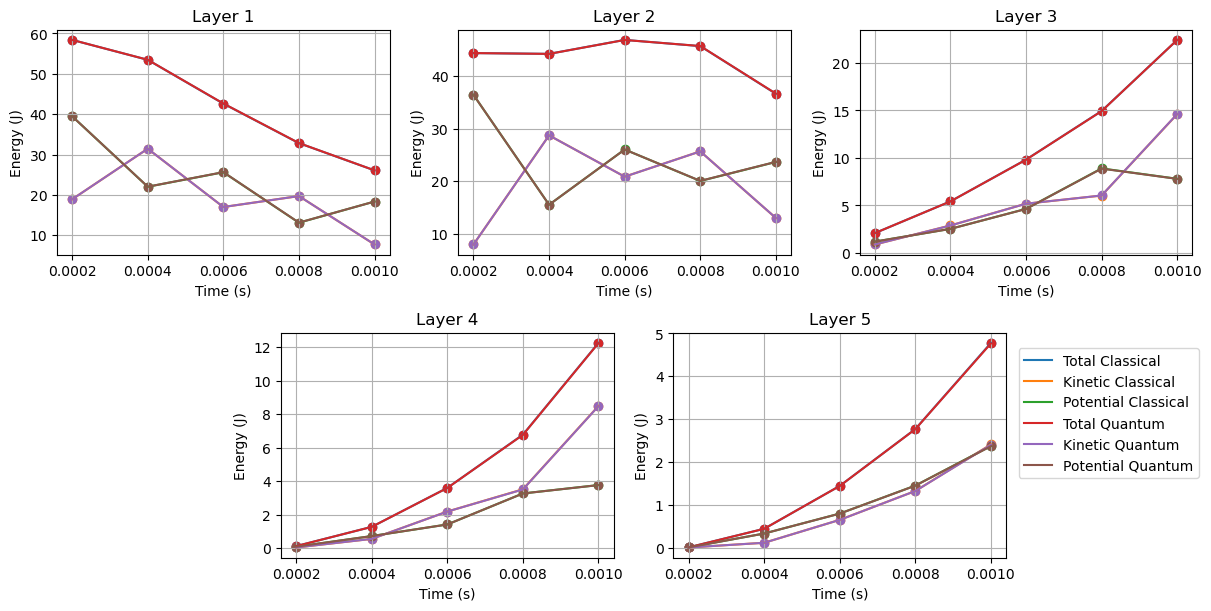

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

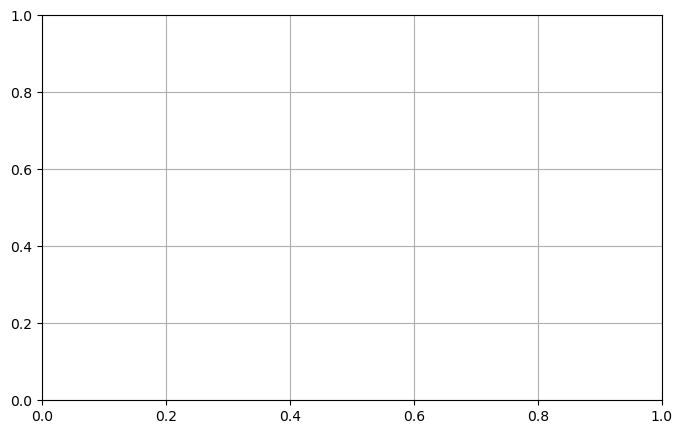

In [141]:
energy_types, times,layer_names = get_layer_dataframes(data)
energy_types, layers, time_names = get_time_dataframes(data)
plot_layer_energy_time(energy_types,times,layer_names)
        

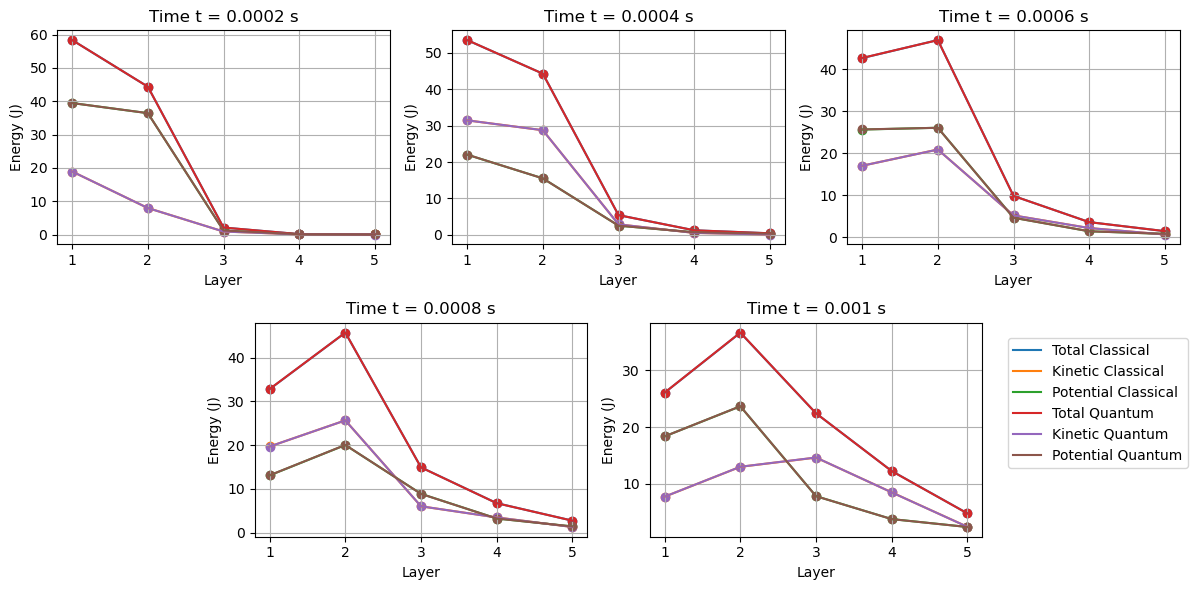

In [142]:
plot_time_energy_layer(energy_types,layers,time_names)